In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [2]:
# Load latest data
data_dir = "../data/raw"
files = glob.glob(f"{data_dir}/stock_prices_*.csv")
latest_file = max(files, key=os.path.getctime)

prices = pd.read_csv(latest_file, index_col=0, parse_dates=True)

prices.head()


,AAPL,AMZN,GOOGL,META,MSFT,NVDA,SPY,TSLA
Date,,,,,,,,
2023-01-03,123.211205,85.820000,88.451691,123.874702,233.985672,14.300685,366.069122,108.099998
2023-01-04,124.482040,85.139999,87.419479,126.486458,223.750381,14.734251,368.895172,113.639999
2023-01-05,123.161942,83.120003,85.553574,126.059441,217.118896,14.250732,364.684875,110.339996
2023-01-06,127.693573,86.080002,86.685020,129.118057,219.677750,14.844139,373.047882,113.059998
2023-01-09,128.215683,87.360001,87.359940,128.571884,221.816559,15.612371,372.836365,119.769997


In [3]:
# Basic info
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 752 entries, 2023-01-03 to 2025-12-31
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    752 non-null    float64
 1   AMZN    752 non-null    float64
 2   GOOGL   752 non-null    float64
 3   META    752 non-null    float64
 4   MSFT    752 non-null    float64
 5   NVDA    752 non-null    float64
 6   SPY     752 non-null    float64
 7   TSLA    752 non-null    float64
dtypes: float64(8)
memory usage: 52.9 KB


In [4]:
prices.isna().sum() 

AAPL     0
AMZN     0
GOOGL    0
META     0
MSFT     0
NVDA     0
SPY      0
TSLA     0
dtype: int64

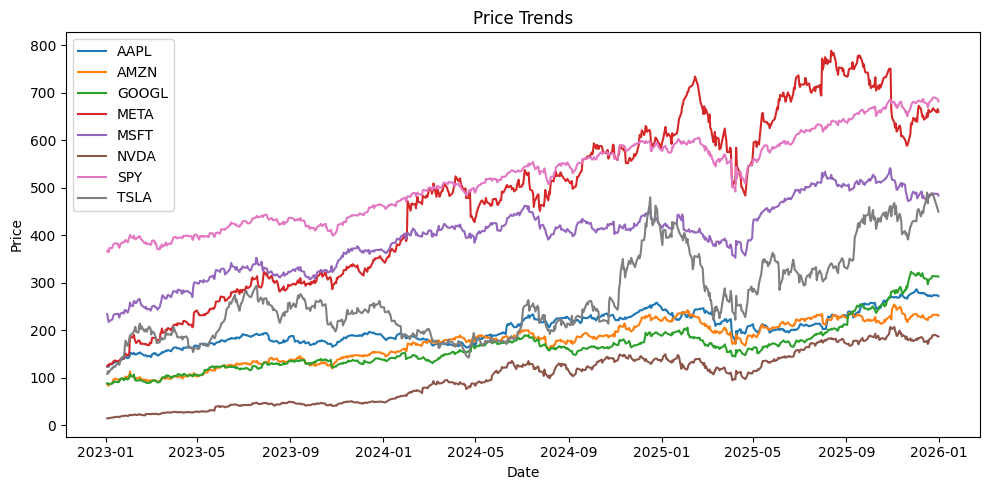

In [5]:
# Price distribution (log scale)
plt.figure(figsize=(10, 5))
for col in prices.columns:
    plt.plot(prices.index, prices[col], label=col)

plt.legend()
plt.title("Price Trends")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

In [6]:
# Daily returns
returns = prices.pct_change().dropna()

returns.describe()

,AAPL,AMZN,GOOGL,META,MSFT,NVDA,SPY,TSLA
count,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000
mean,0.001183,0.001520,0.001865,0.002510,0.001073,0.003917,0.000875,0.002606
std,0.016127,0.020118,0.019071,0.024035,0.014618,0.031637,0.009670,0.037834
min,-0.092456,-0.089791,-0.095094,-0.113348,-0.061809,-0.169682,-0.058543,-0.154262
25%,-0.006645,-0.009504,-0.008650,-0.009641,-0.006760,-0.013611,-0.003384,-0.018660
50%,0.001317,0.000797,0.002329,0.001369,0.001250,0.003669,0.001026,0.001471
75%,0.008694,0.013214,0.011627,0.013013,0.009155,0.021566,0.005953,0.022430
max,0.153288,0.119770,0.102243,0.232824,0.101337,0.243696,0.105019,0.226900


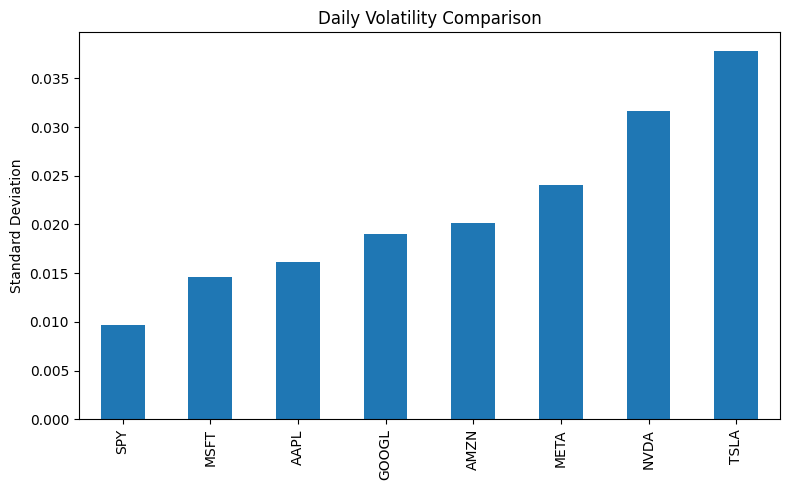

In [7]:
plt.figure(figsize=(8, 5))
returns.std().sort_values().plot(kind="bar")
plt.title("Daily Volatility Comparison")
plt.ylabel("Standard Deviation")
plt.tight_layout()
plt.show()